# Supplementary Figure SR2 — colocalisation clusters by MAF bin

Rare variants are under-represented in the dataset, a consequence of the quality-control filters
(Supplementary Results 6). One bar per MAF bin over the 20,041 colocalisation clusters, each cluster
taken at the minor allele frequency of its representative lead variant — the same cluster table and
the same bins as Figure 3a, read from `cluster_covariates`.

Recovered from `chapters/_legacy/03-manuscript-figures/figure_3/python_scripts/clustering_analysis.ipynb`,
cell 26, which is the code the published figure was drawn with.

**The bars moved with the cluster representative.** The representative is now the lead variant of the
cluster's seed credible set — the member with the smallest association P value — rather than the lead
variant associated with the most diseases (see `chapters/02-analysis-main/README.md`). This figure is
a count of clusters at the representative's MAF, so that is the only change that reaches it; neither
the lead_vPS redefinition nor its sign gate does.

Writes `figure_sr2.pdf`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from manuscript_methods import paper

FIGURE_DIR = paper.ROOT / "chapters" / "05-figures-supplementary" / "supplementary"
MAF_BINS = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
MAF_BIN_LABELS = ["0-0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5"]

clusters = pd.read_parquet(paper.derived("cluster_covariates"))
clusters["maxMAF_bin"] = pd.cut(clusters["maxMAF"], bins=MAF_BINS, labels=MAF_BIN_LABELS, right=False)
assert len(clusters) == 20041, len(clusters)
print(f"clusters: {len(clusters):,}")

clusters: 20,041


## Clusters per MAF bin

In [2]:
counts = clusters.groupby("maxMAF_bin", observed=False).size().rename("clusters")
print(counts.to_string())
print(f"\ntotal: {counts.sum():,}")

maxMAF_bin
0-0.01        496
0.01-0.05    2360
0.05-0.1     1849
0.1-0.2      3579
0.2-0.3      3823
0.3-0.4      3877
0.4-0.5      4055

total: 20,039


## The figure

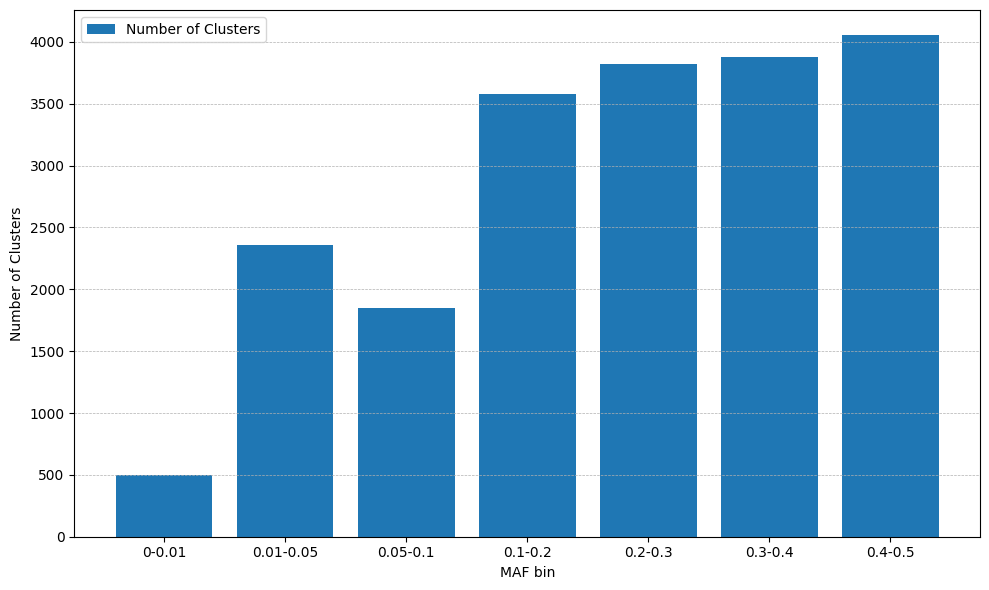

saved figure_sr2.pdf


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(counts.index.astype(str), counts.to_numpy(), label="Number of Clusters")
ax.set_xlabel("MAF bin")
ax.set_ylabel("Number of Clusters")
ax.legend()
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "figure_sr2.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved figure_sr2.pdf")

Against the published PNG (`figures/figure_sr2.png`) the bars were 496, 2,372, 1,868, 3,529, 3,843,
3,867, 4,065 — the counts under the most-diseases representative, which this notebook reproduced
exactly before the representative changed. Under the seed representative they are the values printed
above. The total is 20,041 either way, and only 20,040 fall inside the bars: the bins are half-open
and stop at 0.5, so a cluster whose representative sits exactly at MAF 0.5 falls outside them. The
published figure drops the same cluster.

The caption mentions 95% confidence intervals; the published figure has none, and neither does this
one — there is no error bar to draw on a count.